# Pemrosesan Data dan Analisis Feature Importance Review Shopee

Notebook ini menyiapkan dataset review Shopee untuk analisis fake review berbasis fitur perilaku. Input utama adalah `data/raw/review_shopee.csv`; label supervised digabung dari `data/raw/train_review_only.csv` memakai kunci `cmtid`; output proses disimpan sebagai `data/processed/review_shopee_processed.csv`.

Pendekatan dipakai: data cleaning, feature engineering, agregasi multi-level, visual audit, lalu feature selection multi-metode. Semua 4,630 review valid dipakai untuk menghitung konteks perilaku user/product/shop, sedangkan 100 review berlabel dipakai khusus untuk evaluasi `feature importance`. Ini menjaga konteks data tetap luas tanpa membuat label buatan untuk row yang tidak berlabel.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
LABEL_MAP = {"original": 0, "fake": 1}
ID_COLUMNS = ["cmtid", "userid", "item_id", "shop_id", "author_shopid", "author_username"]
NUMERIC_COLUMNS = [
    "cat_id",
    "count_rating_with_image",
    "count_with_context",
    "ctime",
    "editable",
    "mtime",
    "rating",
    "rating_count0",
    "rating_count1",
    "rating_count2",
    "rating_count3",
    "rating_count4",
    "rating_count5",
    "rating_star",
]


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Project root with pyproject.toml and data/raw not found.")


PROJECT_ROOT = find_project_root()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "review_shopee.csv"
TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "train_review_only.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "review_shopee_processed.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data: {RAW_PATH.relative_to(PROJECT_ROOT)}")
print(f"Train labels: {TRAIN_PATH.relative_to(PROJECT_ROOT)}")
print(f"Output: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")


Project root: C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection
Raw data: data\raw\review_shopee.csv
Train labels: data\raw\train_review_only.csv
Output: data\processed\review_shopee_processed.csv


## 1. Load Data dan Preview 10 Record Pertama

Fase ini membaca file raw sebagai teks agar ID seperti `cmtid`, `userid`, `item_id`, dan `shop_id` tidak berubah format. Sepuluh record pertama ditampilkan apa adanya untuk audit awal.

Ditemukan baris kosong hasil parsing CSV: semua field kosong dan tidak membawa informasi review. Baris ini dibuang sebelum analisis agar jumlah review, agregasi, dan statistik tidak bias.

In [2]:
raw_original = pd.read_csv(RAW_PATH, dtype=str, keep_default_na=False)
train_original = pd.read_csv(TRAIN_PATH, dtype=str, keep_default_na=False)

raw_preview = raw_original.head(10)
print(f"Raw parsed rows: {len(raw_original):,}")
print(f"Train label rows: {len(train_original):,}")
display(raw_preview)


Raw parsed rows: 9,260
Train label rows: 100


,anonymous,author_shopid,author_username,cat_id,cmtid,comment,count_rating_with_image,count_with_context,ctime,editable,...,rating,rating_count0,rating_count1,rating_count2,rating_count3,rating_count4,rating_count5,rating_star,shop_id,userid
0,,,,,,,,,,,...,,,,,,,,,,
1,FALSE,15568078,partianadewi,3268,1940509251,work tp proses lama,0,5,1578476213,0,...,1,20,0,0,0,0,14,5,121336544,15569414
2,,,,,,,,,,,...,,,,,,,,,,
3,FALSE,140322961,arvie2003,3268,1925998607,"Respon cepat, work, dan proses agak lama",0,5,1578085410,0,...,1,20,0,0,0,0,14,5,121336544,140324785
4,,,,,,,,,,,...,,,,,,,,,,
5,FALSE,129737336,rama171200,3268,1923212801,Mantull work,0,5,1578014165,0,...,1,20,0,0,0,0,14,5,121336544,129739160
6,,,,,,,,,,,...,,,,,,,,,,
7,FALSE,60908796,tokkibaechu23,3268,1942090233,,0,5,1578506621,0,...,1,20,0,0,0,0,14,5,121336544,60910238
8,,,,,,,,,,,...,,,,,,,,,,
9,FALSE,176362338,theosetyawan10,3268,1941691729,,0,5,1578494285,0,...,1,20,0,0,0,0,14,5,121336544,176364847


## 2. Preprocessing dan Feature Engineering Review-Level

Fase ini membersihkan row valid dan membangun fitur dasar per review. Metode yang dipakai: normalisasi ID menjadi string, casting kolom numerik, konversi `ctime`/`mtime` dari Unix timestamp ke datetime, serta cleaning teks dengan lowercase dan normalisasi whitespace.

Fitur review-centric dibuat dari panjang teks, jumlah kata, rasio kata unik, komentar kosong, komentar duplikat, rating deviation, edit delay, dan proxy proporsi review bergambar. Efeknya: review mentah berubah menjadi representasi numerik yang bisa dipakai untuk visualisasi, agregasi, dan model feature selection.

`count_rating_with_image` diperlakukan sebagai proxy konteks item, bukan flag gambar per review, karena dataset tidak menyediakan kolom gambar individual.

In [3]:
def normalize_text(value: object) -> str:
    if pd.isna(value):
        return ""
    text = str(value).replace("\r", " ").replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


def normalize_id_series(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip()


def word_count(text: str) -> int:
    if not text:
        return 0
    return len(text.split())


def unique_word_ratio(text: str) -> float:
    tokens = text.split()
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)


def max_repeated_char_run(text: str) -> int:
    if not text:
        return 0
    runs = [len(match.group(0)) for match in re.finditer(r"(.)\1+", text)]
    return max(runs) if runs else 1


def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    denominator = denominator.replace(0, np.nan)
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan)


def prepare_raw_reviews(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()

    for column in ID_COLUMNS:
        if column in df.columns:
            df[column] = normalize_id_series(df[column])

    df = df[df["cmtid"].ne("")].copy()
    if df["cmtid"].duplicated().any():
        duplicate_count = int(df["cmtid"].duplicated().sum())
        raise ValueError(f"Duplicate cmtid in raw data: {duplicate_count}")

    for column in NUMERIC_COLUMNS:
        if column in df.columns:
            df[f"{column}_num"] = pd.to_numeric(df[column], errors="coerce")

    df["review_datetime"] = pd.to_datetime(df["ctime_num"], unit="s", errors="coerce")
    df["mtime_datetime"] = pd.to_datetime(df["mtime_num"], unit="s", errors="coerce")
    df = df[df["review_datetime"].notna()].copy()
    df["review_date"] = df["review_datetime"].dt.date
    df["review_hour"] = df["review_datetime"].dt.hour
    df["review_dayofweek"] = df["review_datetime"].dt.dayofweek
    df["edit_delay_hours"] = (df["mtime_datetime"] - df["review_datetime"]).dt.total_seconds() / 3600
    df["edit_delay_hours"] = df["edit_delay_hours"].fillna(0).clip(lower=0)

    df["comment_clean"] = df["comment"].map(normalize_text)
    df["comment_char_count"] = df["comment_clean"].str.len()
    df["comment_word_count"] = df["comment_clean"].map(word_count)
    df["comment_unique_word_ratio"] = df["comment_clean"].map(unique_word_ratio)
    df["empty_comment_flag"] = df["comment_clean"].eq("").astype(int)
    df["repeated_char_run_max"] = df["comment_clean"].map(max_repeated_char_run)

    nonempty_comment = df["comment_clean"].ne("")
    df["duplicate_comment_flag"] = (nonempty_comment & df.duplicated("comment_clean", keep=False)).astype(int)

    df["rating_star_num"] = pd.to_numeric(df["rating_star"], errors="coerce")
    df["product_rating_mean_context"] = df.groupby("item_id")["rating_star_num"].transform("mean")
    df["rating_deviation_from_product_mean"] = df["rating_star_num"] - df["product_rating_mean_context"]
    df["rating_abs_deviation_from_product_mean"] = df["rating_deviation_from_product_mean"].abs()

    image_count = df["count_rating_with_image_num"].fillna(0)
    context_count = df["count_with_context_num"].fillna(0)
    df["image_review_share_proxy"] = safe_divide(image_count, context_count).fillna(0).clip(lower=0, upper=1)

    return df


raw_valid = prepare_raw_reviews(raw_original)
blank_rows = len(raw_original) - len(raw_valid)

summary = pd.DataFrame(
    [
        {"metric": "raw_parsed_rows", "value": len(raw_original)},
        {"metric": "blank_or_invalid_rows_removed", "value": blank_rows},
        {"metric": "valid_review_rows", "value": len(raw_valid)},
        {"metric": "unique_cmtid", "value": raw_valid["cmtid"].nunique()},
        {"metric": "time_min", "value": raw_valid["review_datetime"].min()},
        {"metric": "time_max", "value": raw_valid["review_datetime"].max()},
    ]
)
display(summary)
display(raw_valid.head(10)[["cmtid", "userid", "item_id", "shop_id", "rating_star", "review_datetime", "comment_clean"]])


,metric,value
0,raw_parsed_rows,9260
1,blank_or_invalid_rows_removed,4630
2,valid_review_rows,4630
3,unique_cmtid,4630
4,time_min,2019-04-04 10:03:56
5,time_max,2020-05-30 04:23:55


,cmtid,userid,item_id,shop_id,rating_star,review_datetime,comment_clean
1,1940509251,15569414,5502846171,121336544,5,2020-01-08 09:36:53,work tp proses lama
3,1925998607,140324785,5502846171,121336544,5,2020-01-03 21:03:30,"respon cepat, work, dan proses agak lama"
5,1923212801,129739160,5502846171,121336544,5,2020-01-03 01:16:05,mantull work
7,1942090233,60910238,5502846171,121336544,5,2020-01-08 18:03:41,
9,1941691729,176364847,5502846171,121336544,5,2020-01-08 14:38:05,
11,1927361691,5507128,5502846171,121336544,5,2020-01-04 07:30:00,
13,2460021850,267520353,7635492260,156138371,5,2020-05-29 05:50:48,"sangat memuaskan belanja di sini, akun origina..."
15,2459972539,267589554,7635492260,156138371,5,2020-05-29 05:41:22,"josss lgs bs login netflix, terpercaya. region..."
17,2459984416,267584975,7635492260,156138371,5,2020-05-29 05:43:33,"netflix berjalan tanpa kendala, admin sgt resp..."
19,2459921646,267601505,7635492260,156138371,5,2020-05-29 05:31:31,"langsung bisa dipakai, pelayanan sgt bagus. th..."


## 3. Merge Label dengan `cmtid`

Fase ini menggabungkan label dari `train_review_only.csv` ke data raw yang sudah diproses menggunakan left join pada `cmtid`. Hanya kolom `cmtid`, `fakeornot`, dan `label` yang diambil dari file train.

Metode ini dipilih untuk mencegah data leakage dari metadata duplikat di file train. Kolom `is_labeled` menandai row yang punya label, sehingga feature importance hanya dihitung pada review berlabel, sementara row lain tetap tersimpan sebagai data proses lengkap.

In [4]:
def prepare_labels(train: pd.DataFrame) -> pd.DataFrame:
    labels = train.copy()
    labels["cmtid"] = normalize_id_series(labels["cmtid"])
    labels["fakeornot"] = labels["fakeornot"].fillna("").astype(str).str.strip().str.lower()
    labels = labels[labels["cmtid"].ne("")].copy()
    if labels["cmtid"].duplicated().any():
        duplicate_count = int(labels["cmtid"].duplicated().sum())
        raise ValueError(f"Duplicate cmtid in train labels: {duplicate_count}")
    labels = labels[labels["fakeornot"].isin(LABEL_MAP)].copy()
    labels["label"] = labels["fakeornot"].map(LABEL_MAP).astype(int)
    return labels[["cmtid", "fakeornot", "label"]]


labels = prepare_labels(train_original)
merged_base = raw_valid.merge(labels, on="cmtid", how="left", validate="one_to_one")
merged_base["is_labeled"] = merged_base["label"].notna()

merge_summary = pd.DataFrame(
    [
        {"metric": "valid_raw_rows", "value": len(raw_valid)},
        {"metric": "train_label_rows", "value": len(labels)},
        {"metric": "labeled_overlap_rows", "value": int(merged_base["is_labeled"].sum())},
        {"metric": "unlabeled_rows", "value": int((~merged_base["is_labeled"]).sum())},
    ]
)
class_counts = merged_base.loc[merged_base["is_labeled"], "fakeornot"].value_counts().rename_axis("label_name").reset_index(name="count")

display(merge_summary)
display(class_counts)


,metric,value
0,valid_raw_rows,4630
1,train_label_rows,100
2,labeled_overlap_rows,100
3,unlabeled_rows,4530


,label_name,count
0,fake,51
1,original,49


## 4. Grouping dan Agregasi Multi-Level

Fase ini membuat fitur perilaku dari lima sudut pandang: review-centric, user-centric, product-centric, shop-centric, dan temporal/behavioral. Pendekatan `groupby` dipakai karena sinyal fake review sering muncul sebagai pola kolektif, bukan hanya dari satu teks review.

User-centric menangkap intensitas dan repetisi akun, product-centric menangkap konsentrasi review dan burst pada produk, shop-centric menangkap pola seller, sedangkan temporal/behavioral menangkap gap waktu dan kepadatan review harian. Agregasi tidak memakai label, sehingga tidak ada target leakage.

In [5]:
def add_group_gap(df: pd.DataFrame, group_col: str, prefix: str) -> pd.DataFrame:
    sorted_df = df.sort_values([group_col, "review_datetime"])
    gap_hours = sorted_df.groupby(group_col)["review_datetime"].diff().dt.total_seconds() / 3600
    result = pd.Series(np.nan, index=df.index, dtype="float64")
    result.loc[gap_hours.index] = gap_hours
    df[f"{prefix}_prev_gap_hours"] = result
    return df


def build_group_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    for group_col, prefix in [("userid", "user"), ("item_id", "product"), ("shop_id", "shop")]:
        result = add_group_gap(result, group_col, prefix)
        same_day = (
            result.groupby([group_col, "review_date"], dropna=False)
            .size()
            .rename(f"{prefix}_reviews_same_day")
            .reset_index()
        )
        result = result.merge(same_day, on=[group_col, "review_date"], how="left")

    user_agg = (
        result.groupby("userid", dropna=False)
        .agg(
            user_review_count=("cmtid", "size"),
            user_rating_mean=("rating_star_num", "mean"),
            user_rating_std=("rating_star_num", "std"),
            user_first_review_at=("review_datetime", "min"),
            user_last_review_at=("review_datetime", "max"),
            user_active_days=("review_date", "nunique"),
            user_mean_gap_hours=("user_prev_gap_hours", "mean"),
            user_unique_products=("item_id", "nunique"),
            user_unique_shops=("shop_id", "nunique"),
            user_empty_comment_rate=("empty_comment_flag", "mean"),
            user_duplicate_comment_rate=("duplicate_comment_flag", "mean"),
        )
        .reset_index()
    )
    user_agg["user_review_span_days"] = (
        (user_agg["user_last_review_at"] - user_agg["user_first_review_at"]).dt.total_seconds() / 86400
    ).fillna(0).clip(lower=0)
    user_agg["user_review_velocity_per_day"] = user_agg["user_review_count"] / user_agg["user_active_days"].clip(lower=1)

    product_agg = (
        result.groupby("item_id", dropna=False)
        .agg(
            product_review_count=("cmtid", "size"),
            product_title_mode=("product_title", lambda value: value.mode().iloc[0] if not value.mode().empty else ""),
            product_rating_mean=("rating_star_num", "mean"),
            product_rating_std=("rating_star_num", "std"),
            product_rating_var=("rating_star_num", "var"),
            product_five_star_share=("rating_star_num", lambda value: float((value == 5).mean())),
            product_first_review_at=("review_datetime", "min"),
            product_last_review_at=("review_datetime", "max"),
            product_active_days=("review_date", "nunique"),
            product_mean_gap_hours=("product_prev_gap_hours", "mean"),
            product_unique_users=("userid", "nunique"),
            product_unique_shops=("shop_id", "nunique"),
            product_empty_comment_rate=("empty_comment_flag", "mean"),
            product_duplicate_comment_rate=("duplicate_comment_flag", "mean"),
            product_image_review_share_proxy=("image_review_share_proxy", "mean"),
            product_max_reviews_per_day=("product_reviews_same_day", "max"),
        )
        .reset_index()
    )
    product_agg["product_review_span_days"] = (
        (product_agg["product_last_review_at"] - product_agg["product_first_review_at"]).dt.total_seconds() / 86400
    ).fillna(0).clip(lower=0)
    product_agg["product_review_velocity_per_day"] = product_agg["product_review_count"] / product_agg["product_active_days"].clip(lower=1)
    product_agg["product_burst_ratio"] = product_agg["product_max_reviews_per_day"] / product_agg["product_review_count"].clip(lower=1)

    shop_agg = (
        result.groupby("shop_id", dropna=False)
        .agg(
            shop_review_count=("cmtid", "size"),
            shop_rating_mean=("rating_star_num", "mean"),
            shop_rating_std=("rating_star_num", "std"),
            shop_rating_var=("rating_star_num", "var"),
            shop_five_star_share=("rating_star_num", lambda value: float((value == 5).mean())),
            shop_first_review_at=("review_datetime", "min"),
            shop_last_review_at=("review_datetime", "max"),
            shop_active_days=("review_date", "nunique"),
            shop_mean_gap_hours=("shop_prev_gap_hours", "mean"),
            shop_unique_users=("userid", "nunique"),
            shop_unique_products=("item_id", "nunique"),
            shop_empty_comment_rate=("empty_comment_flag", "mean"),
            shop_duplicate_comment_rate=("duplicate_comment_flag", "mean"),
            shop_image_review_share_proxy=("image_review_share_proxy", "mean"),
            shop_max_reviews_per_day=("shop_reviews_same_day", "max"),
        )
        .reset_index()
    )
    shop_agg["shop_review_span_days"] = (
        (shop_agg["shop_last_review_at"] - shop_agg["shop_first_review_at"]).dt.total_seconds() / 86400
    ).fillna(0).clip(lower=0)
    shop_agg["shop_review_velocity_per_day"] = shop_agg["shop_review_count"] / shop_agg["shop_active_days"].clip(lower=1)
    shop_agg["shop_burst_ratio"] = shop_agg["shop_max_reviews_per_day"] / shop_agg["shop_review_count"].clip(lower=1)

    result = result.merge(user_agg, on="userid", how="left", validate="many_to_one")
    result = result.merge(product_agg, on="item_id", how="left", validate="many_to_one")
    result = result.merge(shop_agg, on="shop_id", how="left", validate="many_to_one")

    fill_zero_patterns = ["_std", "_var", "_gap_hours", "_rate", "_ratio", "_share_proxy"]
    for column in result.select_dtypes(include=["number"]).columns:
        if any(pattern in column for pattern in fill_zero_patterns):
            result[column] = result[column].fillna(0)

    return result


processed = build_group_features(merged_base)

FEATURE_GROUPS = {
    "comment_char_count": "review",
    "comment_word_count": "review",
    "comment_unique_word_ratio": "review",
    "empty_comment_flag": "review",
    "duplicate_comment_flag": "review",
    "repeated_char_run_max": "review",
    "rating_star_num": "review",
    "rating_deviation_from_product_mean": "review",
    "rating_abs_deviation_from_product_mean": "review",
    "edit_delay_hours": "review",
    "image_review_share_proxy": "review",
    "review_hour": "temporal",
    "review_dayofweek": "temporal",
    "user_prev_gap_hours": "temporal",
    "product_prev_gap_hours": "temporal",
    "shop_prev_gap_hours": "temporal",
    "user_reviews_same_day": "temporal",
    "product_reviews_same_day": "temporal",
    "shop_reviews_same_day": "temporal",
    "user_review_count": "user",
    "user_rating_mean": "user",
    "user_rating_std": "user",
    "user_active_days": "user",
    "user_review_span_days": "user",
    "user_review_velocity_per_day": "user",
    "user_mean_gap_hours": "user",
    "user_unique_products": "user",
    "user_unique_shops": "user",
    "user_empty_comment_rate": "user",
    "user_duplicate_comment_rate": "user",
    "product_review_count": "product",
    "product_rating_mean": "product",
    "product_rating_std": "product",
    "product_rating_var": "product",
    "product_five_star_share": "product",
    "product_active_days": "product",
    "product_review_span_days": "product",
    "product_review_velocity_per_day": "product",
    "product_mean_gap_hours": "product",
    "product_unique_users": "product",
    "product_unique_shops": "product",
    "product_empty_comment_rate": "product",
    "product_duplicate_comment_rate": "product",
    "product_image_review_share_proxy": "product",
    "product_max_reviews_per_day": "product",
    "product_burst_ratio": "product",
    "shop_review_count": "shop",
    "shop_rating_mean": "shop",
    "shop_rating_std": "shop",
    "shop_rating_var": "shop",
    "shop_five_star_share": "shop",
    "shop_active_days": "shop",
    "shop_review_span_days": "shop",
    "shop_review_velocity_per_day": "shop",
    "shop_mean_gap_hours": "shop",
    "shop_unique_users": "shop",
    "shop_unique_products": "shop",
    "shop_empty_comment_rate": "shop",
    "shop_duplicate_comment_rate": "shop",
    "shop_image_review_share_proxy": "shop",
    "shop_max_reviews_per_day": "shop",
    "shop_burst_ratio": "shop",
}

feature_columns = [column for column in FEATURE_GROUPS if column in processed.columns]
print(f"Processed rows: {len(processed):,}")
print(f"Candidate engineered features: {len(feature_columns):,}")
display(processed[["cmtid", "fakeornot", "is_labeled", "comment_char_count", "user_review_count", "product_review_count", "shop_review_count"]].head(10))


Processed rows: 4,630
Candidate engineered features: 62


,cmtid,fakeornot,is_labeled,comment_char_count,user_review_count,product_review_count,shop_review_count
0,1940509251,original,True,19,1,6,6
1,1925998607,NaN,False,40,1,6,6
2,1923212801,NaN,False,12,1,6,6
3,1942090233,NaN,False,0,1,6,6
4,1941691729,NaN,False,0,5,6,6
5,1927361691,NaN,False,0,1,6,6
6,2460021850,original,True,92,4,14,64
7,2459972539,original,True,72,1,14,64
8,2459984416,original,True,65,1,14,64
9,2459921646,NaN,False,51,1,14,64


## 5. Simpan Data Hasil Proses

Fase ini menyimpan semua 4,630 review valid ke `data/processed/review_shopee_processed.csv`. File output berisi kolom raw yang sudah dinormalisasi, fitur engineered, fitur agregasi, `fakeornot`, `label`, dan `is_labeled`.

Label bersifat nullable: hanya 100 row overlap dengan `train_review_only.csv` yang memiliki label. Desain ini membuat file tetap berguna untuk eksplorasi full raw data dan analisis supervised pada subset berlabel.

In [6]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
processed.to_csv(OUTPUT_PATH, index=False)

output_summary = pd.DataFrame(
    [
        {"metric": "output_path", "value": str(OUTPUT_PATH.relative_to(PROJECT_ROOT))},
        {"metric": "processed_rows", "value": len(processed)},
        {"metric": "labeled_rows", "value": int(processed["is_labeled"].sum())},
        {"metric": "selected_candidate_feature_count", "value": len(feature_columns)},
    ]
)
display(output_summary)


,metric,value
0,output_path,data\processed\review_shopee_processed.csv
1,processed_rows,4630
2,labeled_rows,100
3,selected_candidate_feature_count,62


## 6. Visualisasi Eksploratif

Fase ini membuat visual untuk audit kualitas data dan pola awal: blank-field rate, distribusi label, produk dengan burst tinggi, dan shop dengan konsentrasi review tinggi.

Visual dipakai sebelum feature selection agar keputusan cleaning dan agregasi dapat dijelaskan secara transparan. Efeknya: pembaca dapat melihat masalah data dan pola perilaku yang mendasari fitur, bukan hanya menerima ranking model.

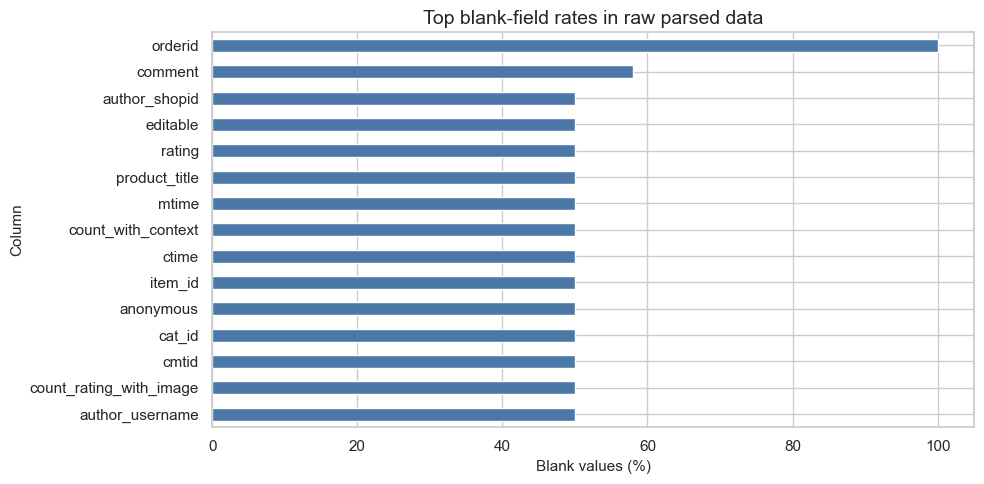

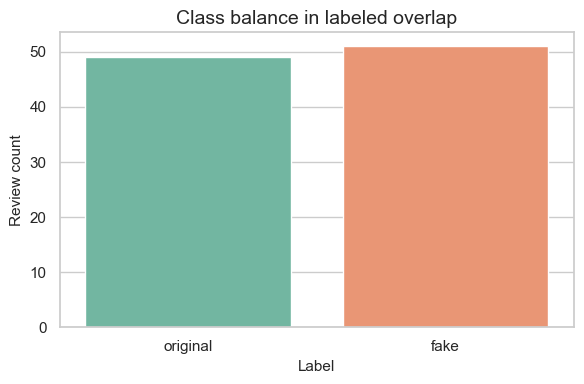

,item_id,product_title_mode,product_review_count,product_max_reviews_per_day,product_burst_ratio,product_five_star_share
1690,6934483509,Netflix Premium UHD 4K Anti OnHold Bergaransi,3,3,1.0,1.0
987,7325321070,NETFLIX PREMIUM 4K UHD RESMI dan LEGAL BERGARANSI,1,1,1.0,1.0
1500,5132331485,TERMURAH!!! NETFLIX PREMIUM 1 BULAN SHARING UHD,1,1,1.0,1.0
1694,4034518996,NETFLIX PREMIUM ANTI ONHOLD,1,1,1.0,1.0
1773,5920692774,SPOTIFY TANPA IKLAN - Spotify Premium,1,1,1.0,1.0
1930,5024428058,Netflix Premium,1,1,1.0,1.0
2059,4813572489,NETFLIX 1 MONTH,1,1,1.0,0.0
2127,6623481709,Netflix Premium + VPN Netflix Indonesia (Subti...,1,1,1.0,1.0
2433,7035316273,NETFLIX PREMIUM RESMI TERPERCAYA (1 BULAN) ULT...,1,1,1.0,1.0
2484,7624125809,NETFLIX PREMIUM 1 BULAN [BERGARANSI],1,1,1.0,1.0


,shop_id,shop_review_count,shop_max_reviews_per_day,shop_burst_ratio,shop_five_star_share,shop_unique_products
1690,227524973,3,3,1.0,1.0,1
987,185074027,1,1,1.0,1.0,1
1500,163066155,1,1,1.0,1.0,1
1694,263897252,1,1,1.0,1.0,1
1930,24679285,1,1,1.0,1.0,1
2059,25898562,1,1,1.0,0.0,1
2127,58018366,1,1,1.0,1.0,1
2433,54587866,1,1,1.0,1.0,1
2484,84839032,1,1,1.0,1.0,1
2960,138504001,1,1,1.0,0.0,1


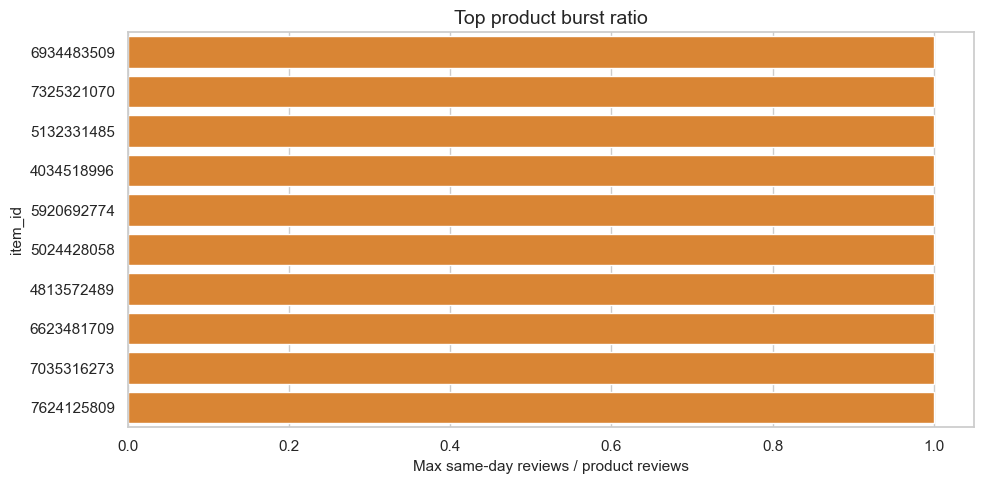

In [7]:
blank_rate = raw_original.astype(str).eq("").mean().mul(100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
blank_rate.head(15).sort_values().plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_title("Top blank-field rates in raw parsed data")
ax.set_xlabel("Blank values (%)")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=processed[processed["is_labeled"]], x="fakeornot", order=["original", "fake"], ax=ax, palette="Set2", hue="fakeornot", legend=False)
ax.set_title("Class balance in labeled overlap")
ax.set_xlabel("Label")
ax.set_ylabel("Review count")
plt.tight_layout()
plt.show()

product_top = (
    processed.drop_duplicates("item_id")
    .sort_values(["product_burst_ratio", "product_max_reviews_per_day", "product_review_count"], ascending=False)
    [["item_id", "product_title_mode", "product_review_count", "product_max_reviews_per_day", "product_burst_ratio", "product_five_star_share"]]
    .head(10)
)
shop_top = (
    processed.drop_duplicates("shop_id")
    .sort_values(["shop_burst_ratio", "shop_max_reviews_per_day", "shop_review_count"], ascending=False)
    [["shop_id", "shop_review_count", "shop_max_reviews_per_day", "shop_burst_ratio", "shop_five_star_share", "shop_unique_products"]]
    .head(10)
)

display(product_top)
display(shop_top)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=product_top, y="item_id", x="product_burst_ratio", ax=ax, color="#f58518")
ax.set_title("Top product burst ratio")
ax.set_xlabel("Max same-day reviews / product reviews")
ax.set_ylabel("item_id")
plt.tight_layout()
plt.show()


## 7. Feature Selection dan Analisis Feature Importance

Target adalah `fakeornot`, dengan encoding `fake=1` dan `original=0`. Kandidat fitur dibatasi pada engineered numeric metadata; ID, teks mentah, timestamp mentah, dan kolom label dikeluarkan.

Pipeline seleksi fitur memakai beberapa tahap: drop fitur dengan missing rate > 40%, median imputation untuk nilai hilang, zero variance filter, lalu Spearman correlation pruning pada `|rho| > 0.90`. Jika dua fitur sangat berkorelasi, fitur dengan `mutual information` lebih tinggi dipertahankan.

Ranking dibuat dengan empat bukti: `mutual information` untuk hubungan non-linear sederhana, `L1 Logistic Regression` untuk seleksi sparse linear, `Random Forest` untuk pola non-linear, dan `permutation importance` untuk mengukur efek fitur terhadap performa validasi. Kombinasi ini dipilih agar hasil tidak bergantung pada satu asumsi model saja.

In [8]:
labeled = processed[processed["is_labeled"]].copy()
labeled["label"] = labeled["label"].astype(int)
y = labeled["label"].astype(int)

X_raw = labeled[feature_columns].apply(pd.to_numeric, errors="coerce")
missing_rate = X_raw.isna().mean()
missing_keep = missing_rate[missing_rate <= 0.40].index.tolist()
X_missing = X_raw[missing_keep]

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X_missing), columns=missing_keep, index=X_missing.index)

variance = X_imputed.var(axis=0)
variance_keep = variance[variance > 0].index.tolist()
X_var = X_imputed[variance_keep]

mi_values = mutual_info_classif(X_var, y, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_values, index=X_var.columns, name="mutual_info")

corr = X_var.corr(method="spearman").abs().fillna(0)
to_drop = set()
columns = list(X_var.columns)
for left_idx, left_col in enumerate(columns):
    if left_col in to_drop:
        continue
    for right_col in columns[left_idx + 1 :]:
        if right_col in to_drop:
            continue
        if corr.loc[left_col, right_col] > 0.90:
            left_mi = mi_series.get(left_col, 0)
            right_mi = mi_series.get(right_col, 0)
            drop_col = right_col if left_mi >= right_mi else left_col
            to_drop.add(drop_col)
            if drop_col == left_col:
                break

X_pool = X_var.drop(columns=sorted(to_drop))
print(f"Labeled rows for feature importance: {len(labeled)}")
print(f"Features after missing filter: {len(missing_keep)}")
print(f"Features after variance filter: {len(variance_keep)}")
print(f"Features removed by correlation pruning: {len(to_drop)}")
print(f"Features ranked: {X_pool.shape[1]}")


Labeled rows for feature importance: 100
Features after missing filter: 62
Features after variance filter: 60
Features removed by correlation pruning: 20
Features ranked: 40


In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

l1_rows = []
rf_rows = []
perm_rows = []
metric_rows = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_pool, y), start=1):
    X_train, X_valid = X_pool.iloc[train_idx], X_pool.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    l1_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    l1_model.fit(X_train, y_train)
    l1_rows.append(pd.Series(np.abs(l1_model.named_steps["clf"].coef_[0]), index=X_pool.columns, name=fold))

    rf_model = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE + fold,
        n_jobs=1,
    )
    rf_model.fit(X_train, y_train)
    rf_rows.append(pd.Series(rf_model.feature_importances_, index=X_pool.columns, name=fold))

    predictions = rf_model.predict(X_valid)
    metric_rows.append(
        {
            "fold": fold,
            "accuracy": accuracy_score(y_valid, predictions),
            "precision": precision_score(y_valid, predictions, zero_division=0),
            "recall": recall_score(y_valid, predictions, zero_division=0),
            "f1": f1_score(y_valid, predictions, zero_division=0),
        }
    )

    perm = permutation_importance(
        rf_model,
        X_valid,
        y_valid,
        scoring="f1",
        n_repeats=25,
        random_state=RANDOM_STATE + fold,
        n_jobs=1,
    )
    perm_rows.append(pd.Series(perm.importances_mean, index=X_pool.columns, name=fold))

l1_importance = pd.DataFrame(l1_rows)
rf_importance = pd.DataFrame(rf_rows)
perm_importance = pd.DataFrame(perm_rows)
cv_metrics = pd.DataFrame(metric_rows)

importance = pd.DataFrame(index=X_pool.columns)
importance["feature"] = importance.index
importance["group"] = importance["feature"].map(FEATURE_GROUPS)
importance["missing_rate"] = missing_rate.reindex(X_pool.columns).fillna(0).values
importance["variance"] = variance.reindex(X_pool.columns).fillna(0).values
importance["mutual_info"] = mi_series.reindex(X_pool.columns).fillna(0).values
importance["l1_abs_coef_mean"] = l1_importance.mean(axis=0).reindex(X_pool.columns).fillna(0).values
importance["rf_importance_mean"] = rf_importance.mean(axis=0).reindex(X_pool.columns).fillna(0).values
importance["permutation_importance_mean"] = perm_importance.mean(axis=0).reindex(X_pool.columns).fillna(0).values
importance["permutation_importance_std"] = perm_importance.std(axis=0).reindex(X_pool.columns).fillna(0).values

rank_sources = [
    ("mutual_info", "mi_rank"),
    ("l1_abs_coef_mean", "l1_rank"),
    ("rf_importance_mean", "rf_rank"),
    ("permutation_importance_mean", "permutation_rank"),
]
for metric, rank_col in rank_sources:
    importance[rank_col] = importance[metric].rank(ascending=False, method="average")

rank_cols = [rank_col for _, rank_col in rank_sources]
importance["consensus_rank_score"] = importance[rank_cols].mean(axis=1)
importance["consensus_rank"] = importance["consensus_rank_score"].rank(ascending=True, method="first").astype(int)
importance = importance.sort_values(["consensus_rank", "permutation_rank", "rf_rank"]).reset_index(drop=True)

selected_features = importance.head(15).copy()
selected_features["consensus_strength"] = selected_features["consensus_rank_score"].max() - selected_features["consensus_rank_score"] + 1

print("Cross-validated Random Forest metrics")
display(cv_metrics)
display(cv_metrics.drop(columns="fold").agg(["mean", "std"]))

display(
    selected_features[
        [
            "consensus_rank",
            "feature",
            "group",
            "missing_rate",
            "mutual_info",
            "mi_rank",
            "l1_abs_coef_mean",
            "l1_rank",
            "rf_importance_mean",
            "rf_rank",
            "permutation_importance_mean",
            "permutation_importance_std",
            "permutation_rank",
            "consensus_rank_score",
        ]
    ]
)


C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Cross-validated Random Forest metrics


,fold,accuracy,precision,recall,f1
0,1,0.95,0.909091,1.000000,0.952381
1,2,0.95,1.000000,0.900000,0.947368
2,3,0.95,1.000000,0.900000,0.947368
3,4,1.00,1.000000,1.000000,1.000000
4,5,0.90,1.000000,0.818182,0.900000


,accuracy,precision,recall,f1
mean,0.950000,0.981818,0.923636,0.949424
std,0.035355,0.040656,0.077299,0.035418


,consensus_rank,feature,group,missing_rate,mutual_info,mi_rank,l1_abs_coef_mean,l1_rank,rf_importance_mean,rf_rank,permutation_importance_mean,permutation_importance_std,permutation_rank,consensus_rank_score
0,1,user_duplicate_comment_rate,user,0.0,0.428417,1.0,1.842752,1.0,0.133234,1.0,0.009969,0.022249,2.0,1.250
1,2,user_unique_shops,user,0.0,0.383387,4.0,0.212698,11.0,0.102890,2.0,0.015222,0.026278,1.0,4.500
2,3,product_duplicate_comment_rate,product,0.0,0.396120,2.0,0.861367,4.0,0.066593,5.0,-0.000553,0.031965,28.0,9.750
3,4,product_active_days,product,0.0,0.365117,5.0,0.000000,32.0,0.046138,6.0,0.009680,0.030877,3.0,11.500
4,5,duplicate_comment_flag,review,0.0,0.336617,7.0,0.000000,32.0,0.075099,3.0,0.001181,0.015506,5.0,11.750
5,6,user_reviews_same_day,temporal,0.0,0.313306,9.0,0.000000,32.0,0.067357,4.0,0.000762,0.016196,6.0,12.750
6,7,product_mean_gap_hours,product,0.0,0.390239,3.0,0.272394,8.0,0.035497,12.0,-0.000822,0.013410,29.0,13.000
7,8,product_review_velocity_per_day,product,0.0,0.305478,10.0,0.000000,32.0,0.045004,7.0,0.008156,0.032557,4.0,13.250
8,9,comment_unique_word_ratio,review,0.0,0.228217,18.0,1.181821,2.0,0.043835,8.0,-0.002286,0.011220,32.0,15.000
9,10,shop_unique_users,shop,0.0,0.191764,24.0,0.231775,10.0,0.013582,19.0,0.000000,0.000000,17.0,17.500


## 8. Bukti Feature Importance Siap Paper

Tabel fase ini menjadi bukti ringkas untuk paper: setiap fitur terpilih punya skor dari beberapa keluarga metode dan rationale berdasarkan kelompok fitur.

Pendekatan multi-metode lebih kuat daripada satu skor importance karena tiap metode punya bias berbeda. Fitur yang konsisten tinggi di beberapa metode lebih defensible sebagai kandidat prediktor fake review.

In [10]:
def rationale_for_group(group: str) -> str:
    rationales = {
        "review": "Captures single-review text/rating behavior that can differ between organic and manipulated reviews.",
        "user": "Captures account-level reviewing intensity, diversity, and repetition patterns.",
        "product": "Captures product-level concentration, rating uniformity, burst, and image-context signals.",
        "shop": "Captures seller-level review concentration and rating behavior across products.",
        "temporal": "Captures timing regularity, same-day density, and gap behavior linked to review bursts.",
    }
    return rationales.get(group, "Engineered behavioral metadata feature.")


proof_table = selected_features[
    [
        "consensus_rank",
        "feature",
        "group",
        "missing_rate",
        "mutual_info",
        "l1_abs_coef_mean",
        "rf_importance_mean",
        "permutation_importance_mean",
        "permutation_importance_std",
        "consensus_rank_score",
    ]
].copy()
proof_table["rationale"] = proof_table["group"].map(rationale_for_group)

display(proof_table)


,consensus_rank,feature,group,missing_rate,mutual_info,l1_abs_coef_mean,rf_importance_mean,permutation_importance_mean,permutation_importance_std,consensus_rank_score,rationale
0,1,user_duplicate_comment_rate,user,0.0,0.428417,1.842752,0.133234,0.009969,0.022249,1.250,"Captures account-level reviewing intensity, di..."
1,2,user_unique_shops,user,0.0,0.383387,0.212698,0.102890,0.015222,0.026278,4.500,"Captures account-level reviewing intensity, di..."
2,3,product_duplicate_comment_rate,product,0.0,0.396120,0.861367,0.066593,-0.000553,0.031965,9.750,"Captures product-level concentration, rating u..."
3,4,product_active_days,product,0.0,0.365117,0.000000,0.046138,0.009680,0.030877,11.500,"Captures product-level concentration, rating u..."
4,5,duplicate_comment_flag,review,0.0,0.336617,0.000000,0.075099,0.001181,0.015506,11.750,Captures single-review text/rating behavior th...
5,6,user_reviews_same_day,temporal,0.0,0.313306,0.000000,0.067357,0.000762,0.016196,12.750,"Captures timing regularity, same-day density, ..."
6,7,product_mean_gap_hours,product,0.0,0.390239,0.272394,0.035497,-0.000822,0.013410,13.000,"Captures product-level concentration, rating u..."
7,8,product_review_velocity_per_day,product,0.0,0.305478,0.000000,0.045004,0.008156,0.032557,13.250,"Captures product-level concentration, rating u..."
8,9,comment_unique_word_ratio,review,0.0,0.228217,1.181821,0.043835,-0.002286,0.011220,15.000,Captures single-review text/rating behavior th...
9,10,shop_unique_users,shop,0.0,0.191764,0.231775,0.013582,0.000000,0.000000,17.500,Captures seller-level review concentration and...


## 9. Visual Feature Importance

Fase ini memvisualisasikan 15 fitur terbaik berdasarkan consensus rank, korelasi Spearman antar fitur teratas, dan distribusi nilai fitur pada label `original` vs `fake`.

Bar plot membantu membaca prioritas fitur, heatmap membantu melihat redundansi antar fitur, dan box/strip plot membantu menilai apakah fitur punya perbedaan pola antar kelas. Visual ini membuat interpretasi model lebih mudah dijelaskan dalam bagian metodologi atau hasil paper.

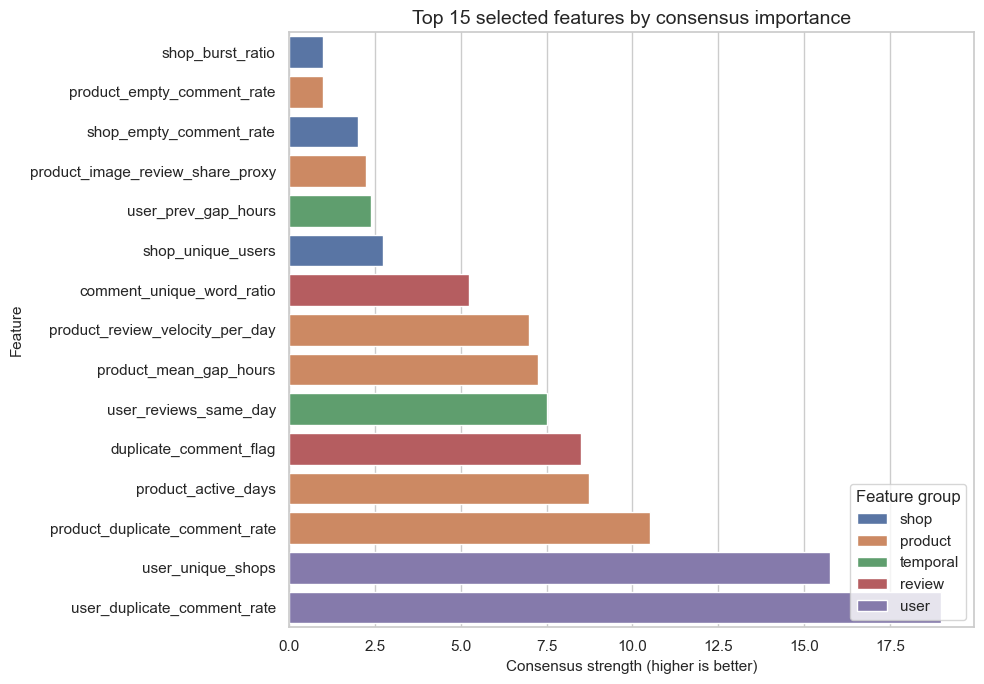

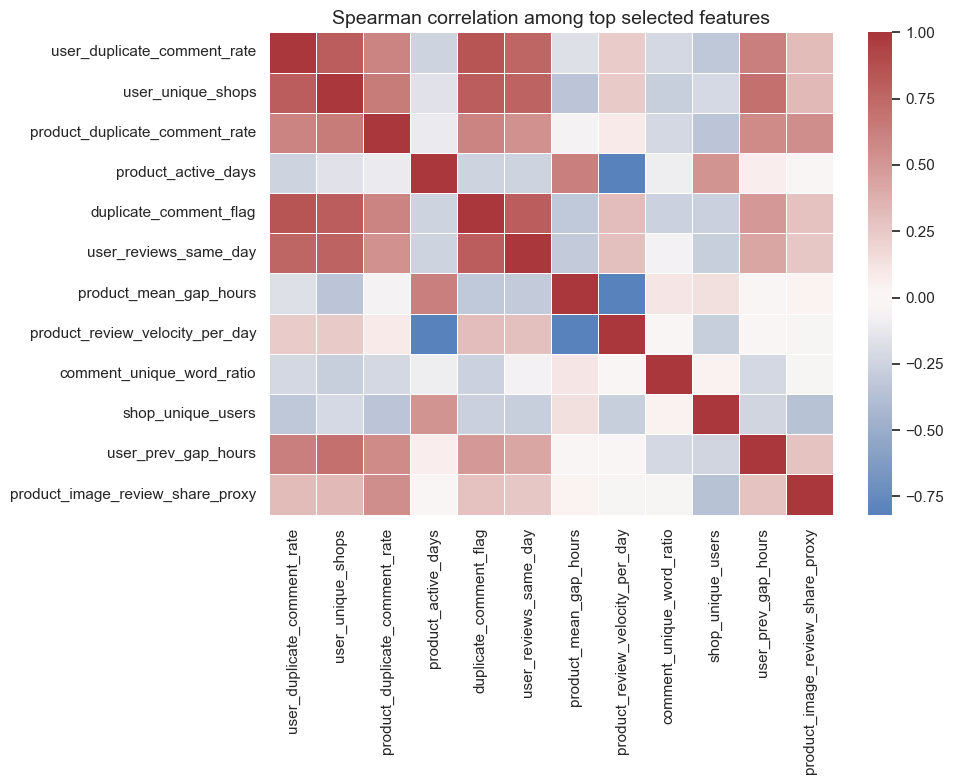

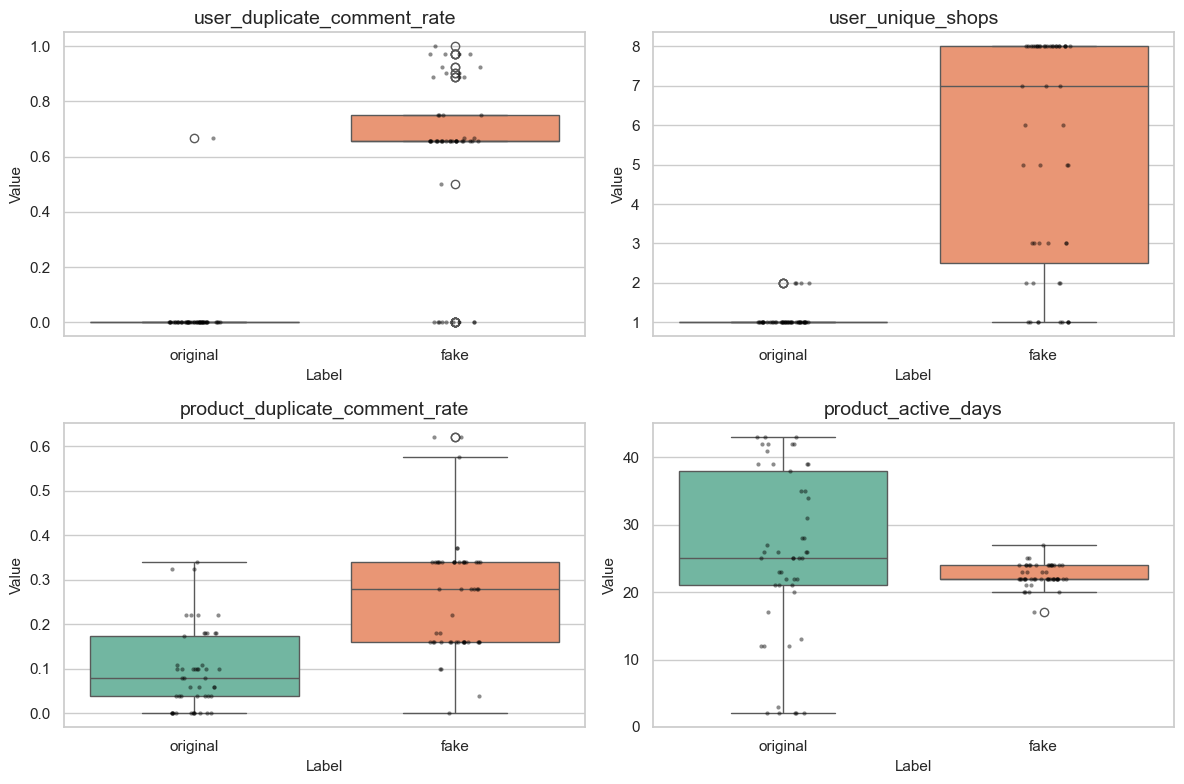

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_data = selected_features.sort_values("consensus_rank", ascending=False)
sns.barplot(data=plot_data, y="feature", x="consensus_strength", hue="group", dodge=False, ax=ax)
ax.set_title("Top 15 selected features by consensus importance")
ax.set_xlabel("Consensus strength (higher is better)")
ax.set_ylabel("Feature")
ax.legend(title="Feature group", loc="lower right")
plt.tight_layout()
plt.show()

corr_cols = selected_features["feature"].head(12).tolist()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(X_pool[corr_cols].corr(method="spearman"), cmap="vlag", center=0, linewidths=0.5, ax=ax)
ax.set_title("Spearman correlation among top selected features")
plt.tight_layout()
plt.show()

dist_features = selected_features["feature"].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, feature in zip(axes, dist_features):
    sns.boxplot(data=labeled, x="fakeornot", y=feature, order=["original", "fake"], ax=ax, hue="fakeornot", palette="Set2", legend=False)
    sns.stripplot(data=labeled, x="fakeornot", y=feature, order=["original", "fake"], ax=ax, color="black", alpha=0.45, size=3)
    ax.set_title(feature)
    ax.set_xlabel("Label")
    ax.set_ylabel("Value")
for ax in axes[len(dist_features) :]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 10. Acceptance Checks

Fase ini menjalankan assertion sebagai kontrak kualitas notebook. Check memastikan output CSV ada, jumlah row proses tetap 4,630, jumlah row berlabel tetap 100, distribusi label tetap `51 fake / 49 original`, dan tabel feature importance tidak kosong.

Assertion dipakai agar perubahan notebook berikutnya tidak diam-diam merusak pipeline data atau bukti feature selection.

In [12]:
assert OUTPUT_PATH.exists(), f"Missing output CSV: {OUTPUT_PATH}"
assert len(processed) == 4630, f"Expected 4,630 processed rows, got {len(processed)}"
assert int(processed["is_labeled"].sum()) == 100, "Expected 100 labeled overlaps"
assert processed.loc[processed["is_labeled"], "fakeornot"].value_counts().to_dict() == {"fake": 51, "original": 49}
assert not selected_features.empty, "Feature importance table is empty"

print("Acceptance checks passed")
print(f"Saved processed data: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")


Acceptance checks passed
Saved processed data: data\processed\review_shopee_processed.csv
